In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/Users/veron/Desktop/clinical appts project/data/cleaned_appointments.csv')
df

,patient_id_fixed,patient_id,patient_name,age,doctor,department,gender_fixed,follow_up_required_fix,identify_currency,billing_amount_fixed,appointment_date_final,booking_date_final,age_bracket,lead_time_category
0,1,1074,Megan Strickland,69,Brandon Lewis,Orthopedics,Female,Yes,EUR,375.24,2025-05-23,2024-06-12,Elderly,Moderate Wait
1,2,1067,Amanda Schroeder,79,Deanna Edwards,Neurology,Male,Yes,EUR,221.64,2025-11-30,2024-08-05,Elderly,Long Wait
2,3,1072,Anthony Mcpherson,47,Karen Parsons,General,Female,No,INR,1.03,2025-05-18,2024-09-09,Middle Aged,Standard Wait
3,4,1057,Joe Sharp,78,Kimberly Fields,General,Unknown,Yes,NaN,200.42,2025-09-26,2025-08-31,Elderly,Standard Wait
4,5,1018,Alexander Harris,22,Jim Jones,Cardiology,Female,No,EUR,107.91,2025-10-30,2024-12-29,Young Adult,Moderate Wait
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,660,1068,Aaron Holder,19,Lauren Ayers,General,Male,Yes,INR,4.53,2026-01-26,2024-11-28,Young Adult,Long Wait
660,661,1082,Thomas Roman,64,Robert Bass,General,Female,Yes,INR,2.41,2025-09-14,2024-07-15,Middle Aged,Long Wait
661,662,1008,Jack Cooper,67,Christopher Smith,General,Female,No,INR,2.93,2025-04-09,2024-06-20,Elderly,Moderate Wait
662,663,1022,Christopher Brown,28,Kimberly Johnson,Neurology,Unknown,No,GBP,196.19,2026-02-13,2024-06-13,Young Adult,Extreme Wait


In [3]:
plt.style.use('ggplot')

In [4]:
df_age = df.groupby(['age_bracket','follow_up_required_fix'])['patient_id_fixed'].count()
df_age = df_age.unstack()
df_age

follow_up_required_fix,No,Yes
age_bracket,,
Elderly,101,142
Middle Aged,104,111
Young Adult,96,110


In [5]:
df_age_yes_rate = df_age['Yes']/(df_age['Yes'] + df_age['No'])
df_age_yes_rate

age_bracket
Elderly        0.584362
Middle Aged    0.516279
Young Adult    0.533981
dtype: float64

In [6]:
df_gender = df.groupby(['gender_fixed','follow_up_required_fix'])['patient_id_fixed'].count()
df_gender = df_gender.unstack()
df_gender

follow_up_required_fix,No,Yes
gender_fixed,,
Female,98,131
Male,98,129
Unknown,105,103


In [7]:
df_gender_yes_rate = df_gender['Yes']/(df_gender['Yes'] + df_gender['No'])
df_gender_yes_rate

gender_fixed
Female     0.572052
Male       0.568282
Unknown    0.495192
dtype: float64

In [8]:
df.groupby('follow_up_required_fix')['billing_amount_fixed'].mean()

follow_up_required_fix
No     224.668671
Yes    223.396474
Name: billing_amount_fixed, dtype: float64

In [9]:
df_department = df.groupby(['department','follow_up_required_fix'])['patient_id_fixed'].count()
df_department = df_department.unstack()
df_department

follow_up_required_fix,No,Yes
department,,
Cardiology,76,79
General,63,88
Neurology,76,105
Orthopedics,86,91


In [10]:
df_department_yes_rate = df_department['Yes']/(df_department['Yes'] + df_department['No'])
df_department_yes_rate

department
Cardiology     0.509677
General        0.582781
Neurology      0.580110
Orthopedics    0.514124
dtype: float64

In [11]:
df_category = df.groupby(['lead_time_category','follow_up_required_fix'])['patient_id_fixed'].count()
df_category = df_category.unstack()
df_category

follow_up_required_fix,No,Yes
lead_time_category,,
Extreme Wait,32,39
Long Wait,42,46
Moderate Wait,72,92
Standard Wait,155,186


In [12]:
df_category_yes_rate = df_category['Yes']/(df_category['Yes'] + df_category['No'])
df_category_yes_rate

lead_time_category
Extreme Wait     0.549296
Long Wait        0.522727
Moderate Wait    0.560976
Standard Wait    0.545455
dtype: float64

## Age, Gender, Department, and Lead Time Category vs Follow Up Required "Yes" Rate as four subplots

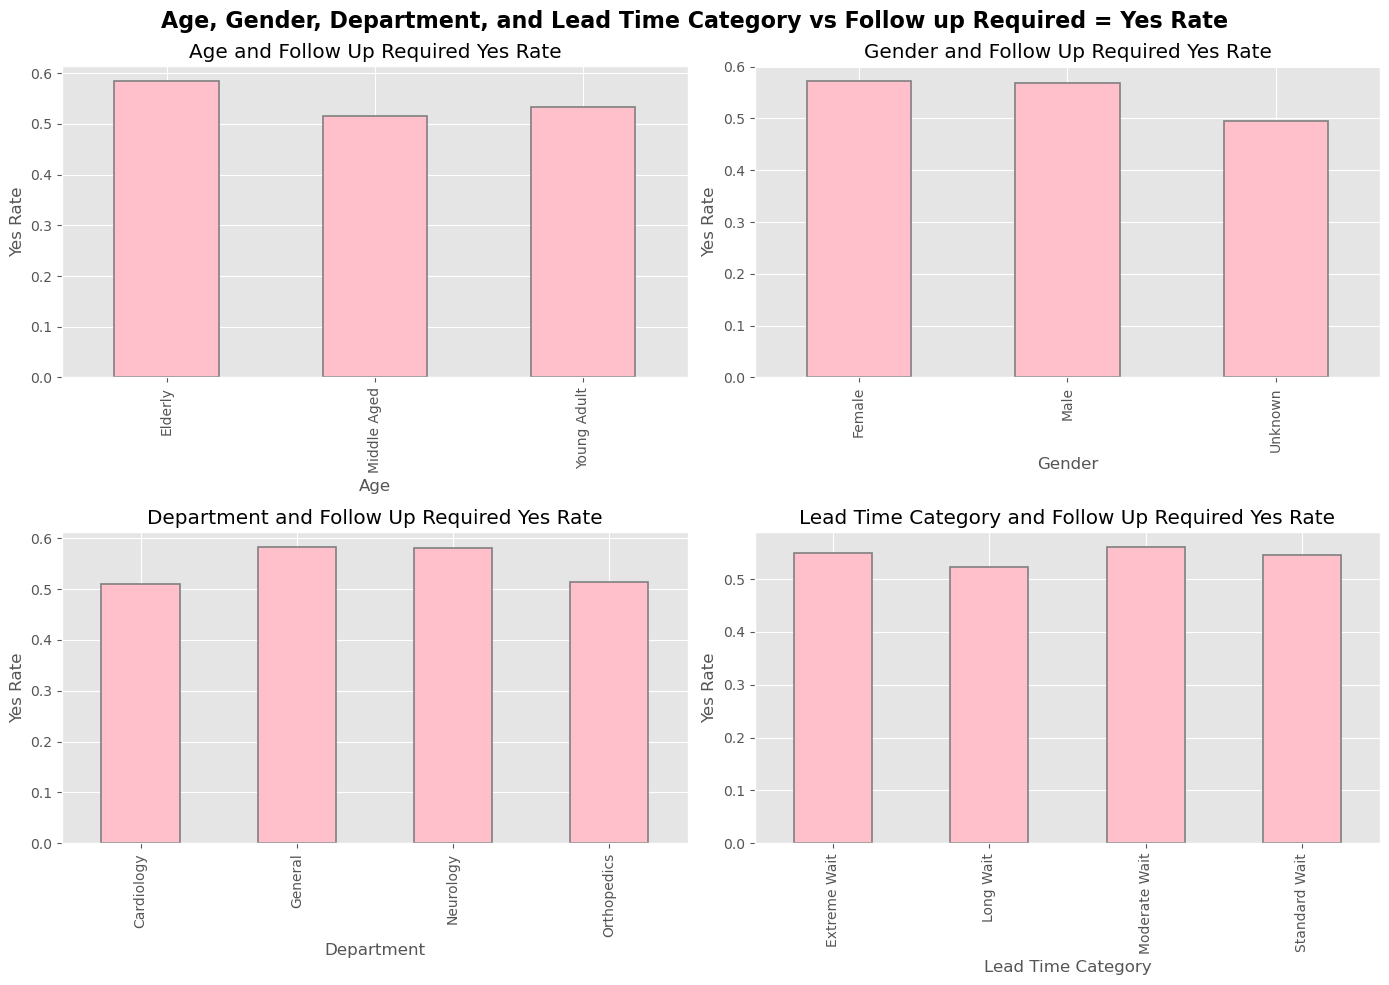

In [39]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
fig.suptitle('Age, Gender, Department, and Lead Time Category vs Follow up Required = Yes Rate', fontsize=16, fontweight='bold')

# top left: age plot
df_age_yes_rate.plot.bar(
    xlabel='Age', 
    ylabel='Yes Rate', 
    ax=axes[0,0], 
    color='pink', 
    edgecolor='grey', 
    linewidth=1.2, 
)
axes[0, 0].set_title('Age and Follow Up Required Yes Rate')

# top right: gender plot
df_gender_yes_rate.plot.bar(
    xlabel='Gender', 
    ylabel='Yes Rate',
    ax=axes[0,1],
    color='pink', 
    edgecolor='grey', 
    linewidth=1.2, 
)
axes[0, 1].set_title('Gender and Follow Up Required Yes Rate')

# bottom left: department plot
df_department_yes_rate.plot.bar(
    xlabel='Department', 
    ylabel='Yes Rate', 
    ax=axes[1,0],
    color='pink', 
    edgecolor='grey', 
    linewidth=1.2, 
)
axes[1, 0].set_title('Department and Follow Up Required Yes Rate')

# bottom right: lead time category
df_category_yes_rate.plot.bar(
    xlabel='Lead Time Category', 
    ylabel='Yes Rate', 
    ax=axes[1,1],
    color='pink', 
    edgecolor='grey', 
    linewidth=1.2, 
)
axes[1, 1].set_title('Lead Time Category and Follow Up Required Yes Rate')

plt.tight_layout()
plt.show()

## Scatter Plot for Age vs. Billing Amount

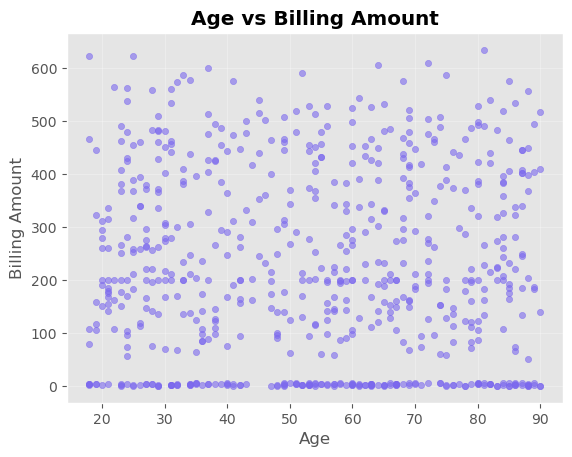

In [14]:
df.plot.scatter(x='age', y='billing_amount_fixed', xlabel='Age', ylabel='Billing Amount', color='mediumslateblue', alpha=0.6)
plt.title('Age vs Billing Amount', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

#### **Note on currency conversion**: Billing amounts were converted from GBP, EUR, and INR to USD using a fixed nominal exchange rate (see `queries/cleaning.sql`). This makes the values numerically comparable, but does **not** account for regional differences in healthcare cost structures. The same converted dollar amount may represent a very different real cost of care depending on the country's healthcare system, labour costs, and cost of living. Cross-currency billing comparisons in this analysis should be read with that limitation in mind, not as a true purchasing-power-adjusted comparison.

#### A useful follow-up would be checking billing patterns *within* each original currency group separately, to see whether currency/region-specific patterns are being masked by the pooled USD figure.

In [15]:
df_currency_describe = df.groupby('identify_currency')['billing_amount_fixed'].describe()
df_currency_describe

,count,mean,std,min,25%,50%,75%,max
identify_currency,,,,,,,,
EUR,164.0,307.074512,148.737739,57.03,172.7525,310.995,444.2575,544.73
GBP,135.0,332.390444,160.017267,75.78,195.1600,306.680,459.3800,634.58
INR,159.0,3.410692,1.567135,0.67,2.0850,3.370,4.7450,6.00
USD,174.0,267.411034,130.681872,51.72,157.0150,249.290,384.4175,498.84


## Scatter Plots for Age vs Billing Amount by Currency

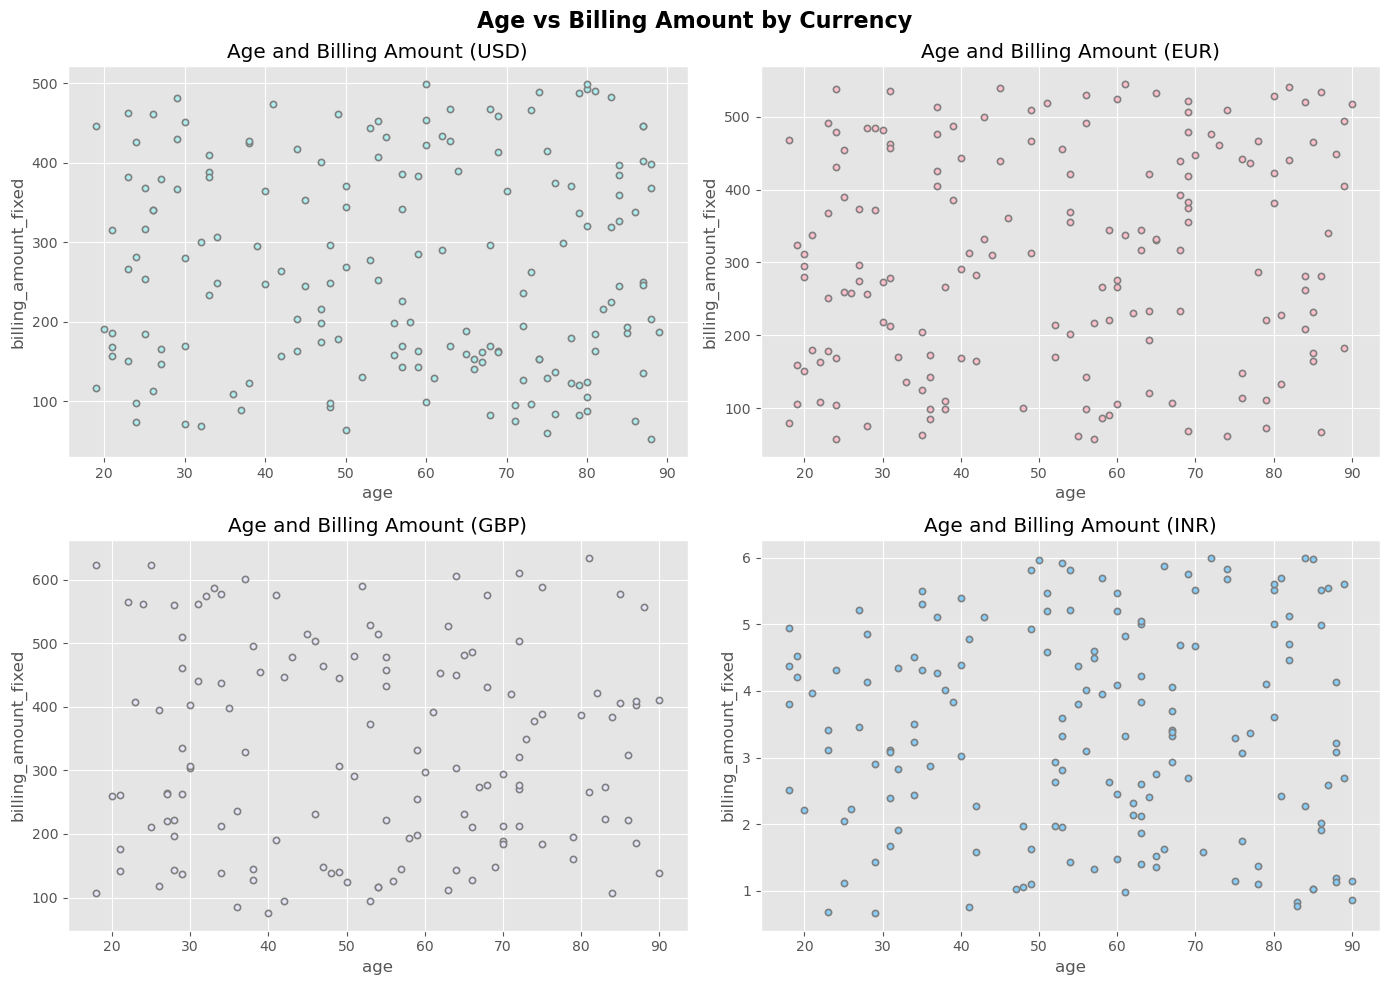

In [16]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
fig.suptitle('Age vs Billing Amount by Currency', fontsize=16, fontweight='bold')

# top left: age plot
df[df['identify_currency'] == 'USD'].plot.scatter(
    x='age', 
    y='billing_amount_fixed', 
    ax=axes[0,0], 
    color='paleturquoise', 
    edgecolor='grey', 
    linewidth=1.2, 
)
axes[0, 0].set_title('Age and Billing Amount (USD)')

# top right: gender plot
df[df['identify_currency'] == 'EUR'].plot.scatter(
    x='age', 
    y='billing_amount_fixed',
    ax=axes[0,1],
    color='pink', 
    edgecolor='grey', 
    linewidth=1.2, 
)
axes[0, 1].set_title('Age and Billing Amount (EUR)')

# bottom left: department plot
df[df['identify_currency'] == 'GBP'].plot.scatter(
    x='age', 
    y='billing_amount_fixed', 
    ax=axes[1,0],
    color='lavender', 
    edgecolor='grey', 
    linewidth=1.2, 
)
axes[1, 0].set_title('Age and Billing Amount (GBP)')

# bottom right: lead time category
df[df['identify_currency'] == 'INR'].plot.scatter(
    x='age', 
    y='billing_amount_fixed', 
    ax=axes[1,1],
    color='lightskyblue', 
    edgecolor='grey', 
    linewidth=1.2, 
)
axes[1, 1].set_title('Age and Billing Amount (INR)')

plt.tight_layout()
plt.show()

In [17]:
df_avg_billing_by_age = df[df['identify_currency'].isin(['USD', 'GBP', 'EUR'])].groupby('age_bracket')['billing_amount_fixed'].mean().reindex(['Young Adult','Middle Aged','Elderly'])
print(df_avg_billing_by_age)

age_bracket
Young Adult    297.934641
Middle Aged    300.264218
Elderly        300.806994
Name: billing_amount_fixed, dtype: float64


## Line plot for Age Bracket vs Billing Amount (Dropped INR)

<Axes: title={'center': 'Age vs Billing Amount'}, xlabel='Age Bracket', ylabel='Billing Amount ($)'>

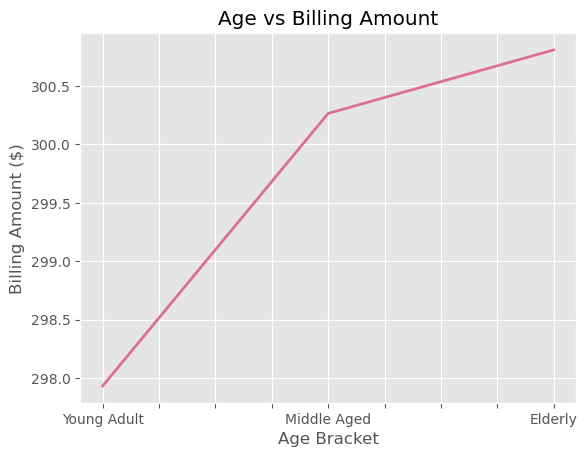

In [40]:
df_avg_billing_by_age.plot(xlabel='Age Bracket', ylabel='Billing Amount ($)', title='Age vs Billing Amount', color='palevioletred', linewidth=2)

In [19]:
df.loc[df['identify_currency'].isin(['USD', 'GBP', 'EUR']), 'appointment_date_final'] = pd.to_datetime(
    df.loc[df['identify_currency'].isin(['USD', 'GBP', 'EUR']), 'appointment_date_final']
)
appointment_date_final = df.loc[df['identify_currency'].isin(['USD', 'GBP', 'EUR']), 'appointment_date_final']
appointment_date_final

0      2025-05-23 00:00:00
1      2025-11-30 00:00:00
4      2025-10-30 00:00:00
6      2025-08-22 00:00:00
7      2026-03-16 00:00:00
              ...         
656    2025-10-21 00:00:00
657    2026-01-12 00:00:00
658    2025-06-13 00:00:00
662    2026-02-13 00:00:00
663    2025-11-05 00:00:00
Name: appointment_date_final, Length: 473, dtype: object

In [20]:
df['appointment_date_final'] = pd.to_datetime(df['appointment_date_final'])
df['appointment_month'] = df['appointment_date_final'].dt.month

In [21]:
df_avg_billing_by_month = df[df['identify_currency'].isin(['USD', 'GBP', 'EUR'])].groupby('appointment_month')['billing_amount_fixed'].mean()

## Line plot for Month vs Billing Amount (INR Dropped)

<Axes: title={'center': 'Month vs Billing Amount'}, xlabel='Month', ylabel='Billing Amount ($)'>

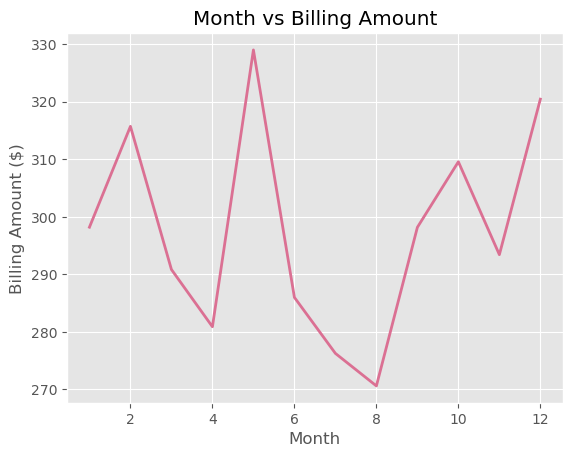

In [41]:
df_avg_billing_by_month.plot(xlabel='Month', ylabel='Billing Amount ($)', title='Month vs Billing Amount', color='palevioletred', linewidth=2)

In [23]:
df_avg_billing_by_dep = df[df['identify_currency'].isin(['USD', 'GBP', 'EUR'])].groupby('department')['billing_amount_fixed'].mean()

## Bar plot for Department vs Billing Amount (INR Dropped)

<Axes: title={'center': 'Department vs Billing Amount'}, xlabel='department', ylabel='Billing Amount ($)'>

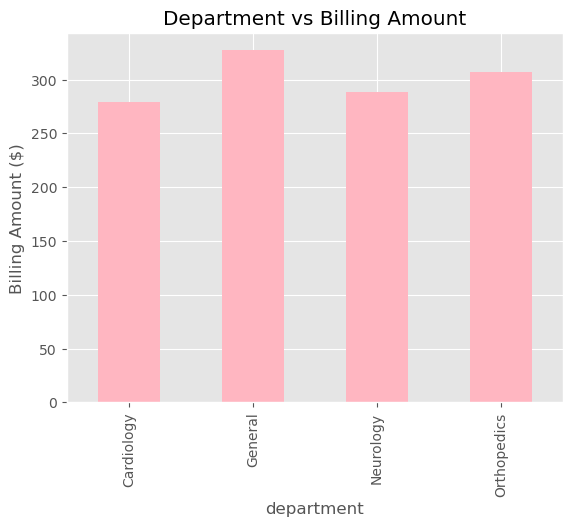

In [42]:
df_avg_billing_by_dep.plot(xlabel='department', ylabel='Billing Amount ($)', kind='bar', title='Department vs Billing Amount', color='lightpink', linewidth=2)

In [25]:
df_lead_time_bill = df[df['identify_currency'].isin(['USD', 'GBP', 'EUR'])].groupby('lead_time_category')['billing_amount_fixed'].mean()

## Bar plot for Lead Time Category vs Billing Amount (INR Dropped)

<Axes: title={'center': 'Lead Time Category vs Billing Amount'}, xlabel='Lead Time Category', ylabel='Billing Amount ($)'>

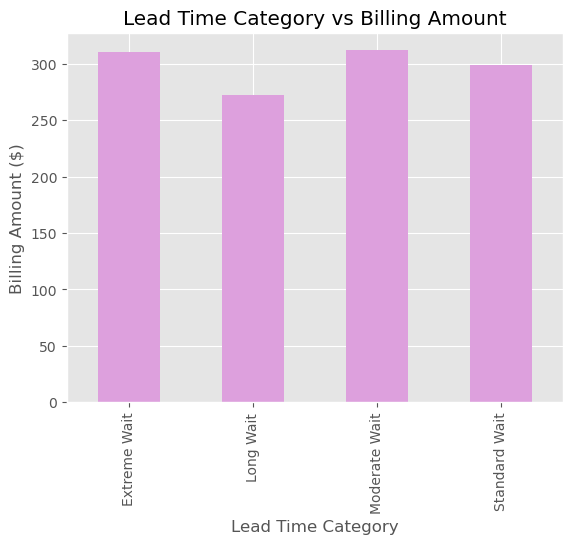

In [43]:
df_lead_time_bill.plot(xlabel='Lead Time Category', ylabel='Billing Amount ($)', kind='bar', title='Lead Time Category vs Billing Amount', color='plum', linewidth=2)

In [27]:
df_lead_time_age = df.groupby('lead_time_category')['age'].mean()

## Bar plot for Lead Time Category vs Avg Age

<Axes: title={'center': 'Lead Time Category vs Avg Age'}, xlabel='Lead Time Category', ylabel='Avg Age'>

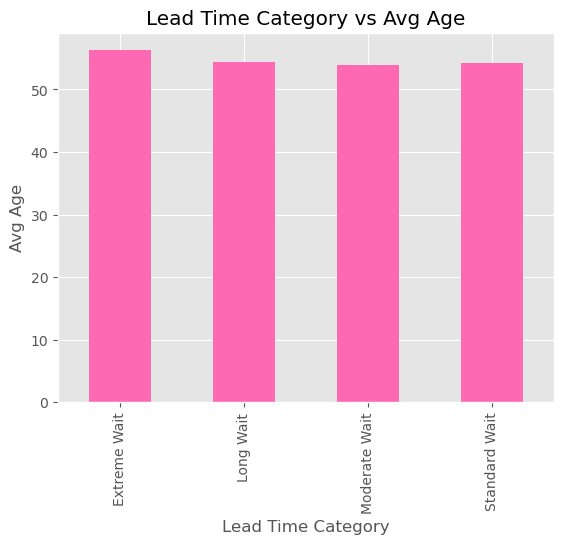

In [44]:
df_lead_time_age.plot(xlabel='Lead Time Category', ylabel='Avg Age', kind='bar', title='Lead Time Category vs Avg Age', color='hotpink', linewidth=2)

In [29]:
df_three_follow_up = df.groupby(['age_bracket', 'department', 'follow_up_required_fix'])['patient_id_fixed'].count()
df_three_follow_up

age_bracket  department   follow_up_required_fix
Elderly      Cardiology   No                        26
                          Yes                       32
             General      No                        22
                          Yes                       35
             Neurology    No                        28
                          Yes                       40
             Orthopedics  No                        25
                          Yes                       35
Middle Aged  Cardiology   No                        23
                          Yes                       24
             General      No                        24
                          Yes                       26
             Neurology    No                        27
                          Yes                       36
             Orthopedics  No                        30
                          Yes                       25
Young Adult  Cardiology   No                        27
                

In [30]:
df_three_follow_up = df_three_follow_up.unstack()
df_three_follow_up

follow_up_required_fix   No  Yes
age_bracket department          
Elderly     Cardiology   26   32
            General      22   35
            Neurology    28   40
            Orthopedics  25   35
Middle Aged Cardiology   23   24
            General      24   26
            Neurology    27   36
            Orthopedics  30   25
Young Adult Cardiology   27   23
            General      17   27
            Neurology    21   29
            Orthopedics  31   31

In [31]:
df_three_rate = df_three_follow_up['Yes']/(df_three_follow_up['Yes'] + df_three_follow_up['No'])
df_three_rate

age_bracket  department 
Elderly      Cardiology     0.551724
             General        0.614035
             Neurology      0.588235
             Orthopedics    0.583333
Middle Aged  Cardiology     0.510638
             General        0.520000
             Neurology      0.571429
             Orthopedics    0.454545
Young Adult  Cardiology     0.460000
             General        0.613636
             Neurology      0.580000
             Orthopedics    0.500000
dtype: float64

In [32]:
df_three_rate = df_three_rate.unstack()
df_three_rate

department,Cardiology,General,Neurology,Orthopedics
age_bracket,,,,
Elderly,0.551724,0.614035,0.588235,0.583333
Middle Aged,0.510638,0.520000,0.571429,0.454545
Young Adult,0.460000,0.613636,0.580000,0.500000


## Heatmap for department and age bracket interaction (follow up required yes rate)

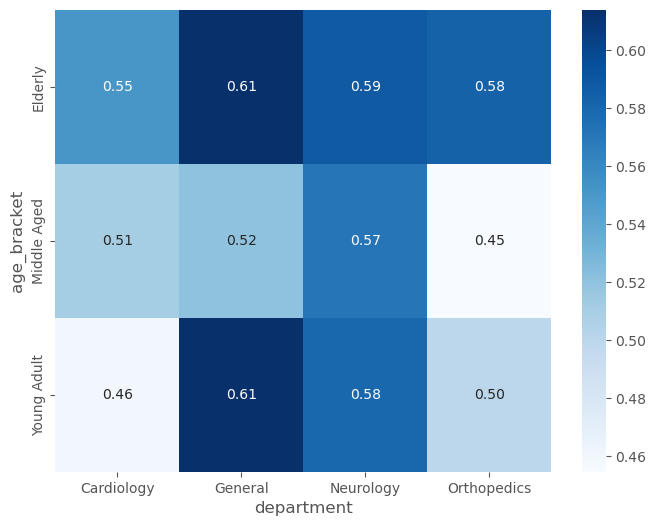

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_three_rate, annot=True, cmap='Blues', fmt=".2f")

plt.show()

In [34]:
df_two_billing = df[df['identify_currency'].isin(['USD', 'GBP', 'EUR'])].groupby(['department', 'age_bracket'])['billing_amount_fixed'].mean().unstack()
df_two_billing

age_bracket,Elderly,Middle Aged,Young Adult
department,,,
Cardiology,300.50814,272.013939,258.757714
General,298.33050,366.861290,324.624706
Neurology,297.64220,279.984681,288.551944
Orthopedics,307.56075,295.288889,314.632708


## Heatmap for department and age bracket interaction (billing amount)

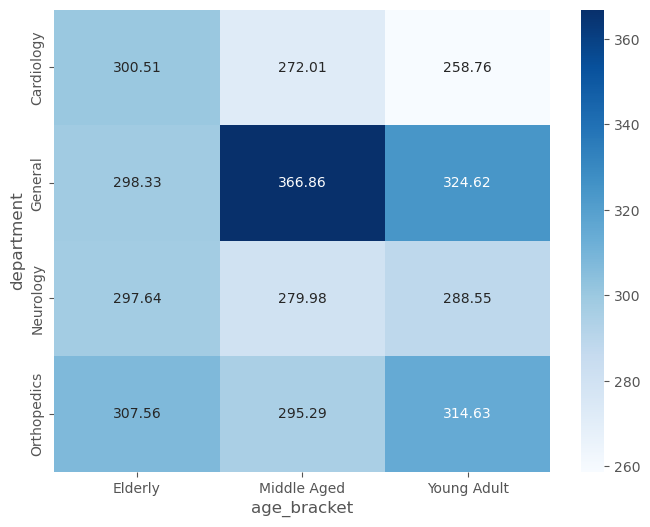

In [35]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_two_billing, annot=True, cmap='Blues', fmt=".2f")

plt.show()

## Statistical Test: Is the Long Wait Billing Difference Significant?

In [36]:
from scipy import stats

sub = df[df['identify_currency'].isin(['USD','GBP','EUR'])]
long_wait = sub[sub['lead_time_category']=='Long Wait']['billing_amount_fixed']
rest = sub[sub['lead_time_category']!='Long Wait']['billing_amount_fixed']

t_stat, p_value = stats.ttest_ind(long_wait, rest, equal_var=False)
print(f'Long Wait: n={len(long_wait)}, mean={long_wait.mean():.2f}')
print(f'Rest:      n={len(rest)}, mean={rest.mean():.2f}')
print(f't-statistic: {t_stat:.3f}')
print(f'p-value: {p_value:.4f}')

Long Wait: n=60, mean=271.92
Rest:      n=413, mean=303.75
t-statistic: -1.489
p-value: 0.1408


## Summary of Findings

**What predicts follow-up care?**
- Age bracket and department both show modest but real relationships with follow-up-required rate (Elderly ~58% vs. Young Adult ~53%; General/Neurology ~58% vs. Cardiology/Orthopedics ~51%).
- Gender, billing amount, and lead time category show no meaningful relationship with follow-up rate.
- The age bracket x department heatmap shows these two effects don't act uniformly together: Neurology's rate stays consistently moderate-high regardless of age, Cardiology shows the clearest age gradient (older patients need more follow-up), and Orthopedics has an unexplained dip for Middle Aged patients.

**Billing patterns**
- No relationship between age and billing amount (correlation approximately 0, both pooled and within each currency).
- No strong month-to-month (seasonal) trend in billing.
- Department shows some variation in average billing, but it falls within normal noise.
- Lead time category: "Long Wait" appointments looked visually lower in average billing than other categories, but a t-test found the difference is **not statistically significant** (p = 0.14) - plausibly due to chance rather than a real effect.

**Data quality note**
- INR-converted billing amounts (average approximately 3.41 USD-equivalent) are dramatically smaller than USD, GBP, and EUR (average approximately 267 to 332 USD) due to the nominal exchange-rate conversion method. This is a documented limitation, and all billing-amount comparisons in this notebook exclude INR to avoid this confound (see note earlier in this notebook).

**Overall**: age bracket and department are the strongest (though still modest) predictors of follow-up need found in this dataset. Most other variables tested show no meaningful relationship - a genuine, honestly-reported finding rather than a failure of the analysis, and a realistic result to carry into the modeling stage.